In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import random
import json
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pycocotools.coco import COCO

In [3]:
# !pip3 install pycocotools

In [4]:
# Define paths to the dataset directories
train_dir = '/kaggle/input/aquarium-dataset/Aquarium Combined/train/'
test_dir = '/kaggle/input/aquarium-dataset/Aquarium Combined/test/'
valid_dir = '/kaggle/input/aquarium-dataset/Aquarium Combined/valid/'

# Using PYCOCOTOOLS

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!


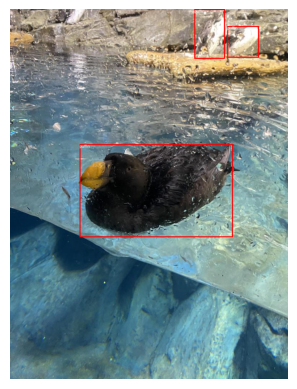

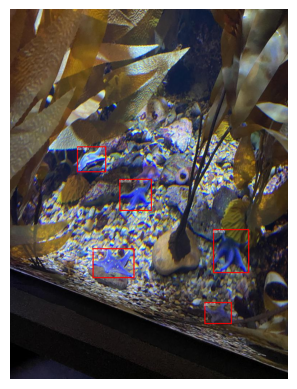

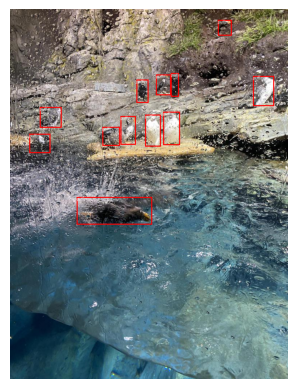

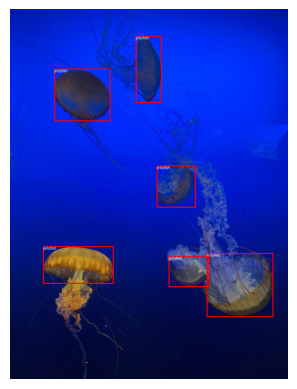

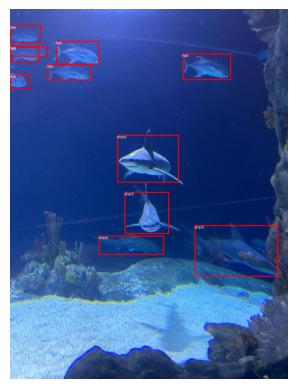

In [5]:
import os
import random
import json
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pycocotools.coco import COCO

# Define paths to the dataset directories
train_dir = '/kaggle/input/aquarium-dataset/Aquarium Combined/train/'
annotations_path = os.path.join(train_dir, '_annotations.coco.json')

# Load the COCO annotations
def load_coco_annotations(annotations_file):
    return COCO(annotation_file=annotations_file)

# Function to visualize image with bounding boxes and labels
def visualize_coco_image(coco, img_dir, img_info):
    img_path = os.path.join(img_dir, img_info['file_name'])
    
    img = Image.open(img_path)
    draw = ImageDraw.Draw(img)

    # Load annotations for this image
    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)
    
    # Draw bounding boxes and class labels
    for ann in anns:
        bbox = ann['bbox']
        category = coco.loadCats(ann['category_id'])[0]['name']  # Get class name
        
        # COCO format: bbox = [x_min, y_min, width, height]
        x_min, y_min, width, height = bbox
        x_max, y_max = x_min + width, y_min + height
        
        # Draw the bounding box
        draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)
        
        # Add the class label on top of the bounding box
        draw.text((x_min, y_min), category, fill="white")
    
    # Show the image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Function to randomly visualize 5 images from the dataset
def visualize_random_images(coco, img_dir):
    img_ids = coco.getImgIds()
    sample_img_ids = random.sample(img_ids, 5)
    
    for img_id in sample_img_ids:
        img_info = coco.loadImgs(img_id)[0]
        visualize_coco_image(coco, img_dir, img_info)

# Load the annotations
coco = load_coco_annotations(annotations_path)

# Visualize random images from the training dataset
visualize_random_images(coco, train_dir)


# Not Using Pycoco tools

In [7]:
import os
import json
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

In [8]:
# Directory path containing the images and the annotations
directory_path = '/kaggle/input/aquarium-dataset/Aquarium Combined/train'

In [9]:
# Load annotations from the JSON file
json_path = os.path.join(directory_path, '_annotations.coco.json')
print(json_path)

/kaggle/input/aquarium-dataset/Aquarium Combined/train/_annotations.coco.json


In [11]:
with open(json_path) as f:
    annotations = json.load(f)
    
# print(annotations)

In [12]:
# Mapping of category IDs to names
category_map = {cat['id']: cat['name'] for cat in annotations['categories']}
print(category_map)

{0: 'creatures', 1: 'fish', 2: 'jellyfish', 3: 'penguin', 4: 'puffin', 5: 'shark', 6: 'starfish', 7: 'stingray'}


In [14]:
# Mapping of image IDs to file names
image_map = {img['id']: img['file_name'] for img in annotations['images']}
# print(image_map)

In [17]:
# Get annotations for each image
image_annotations = {}
print(image_annotations)
for ann in annotations['annotations']:
    img_id = ann['image_id']
    # print("******* Inside Loop *******")
    if img_id not in image_annotations:
        image_annotations[img_id] = []
    image_annotations[img_id].append(ann)
# image_annotations


{}


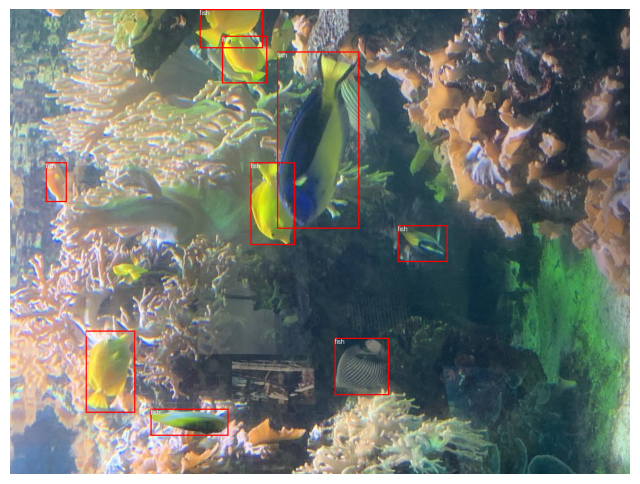

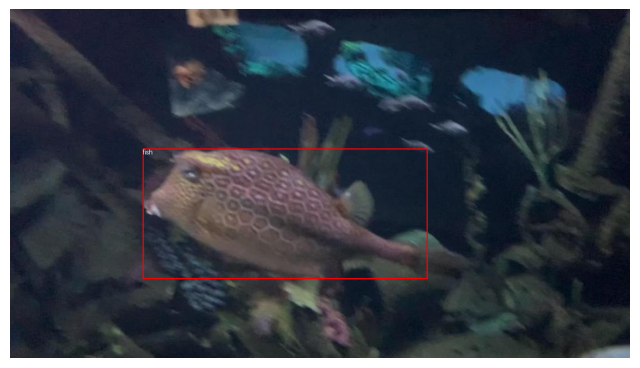

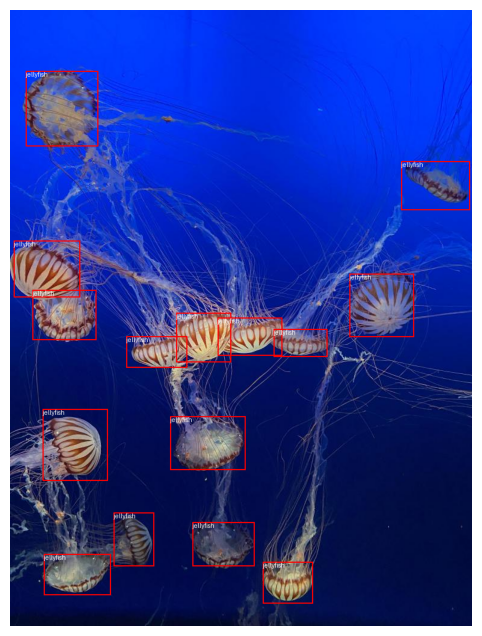

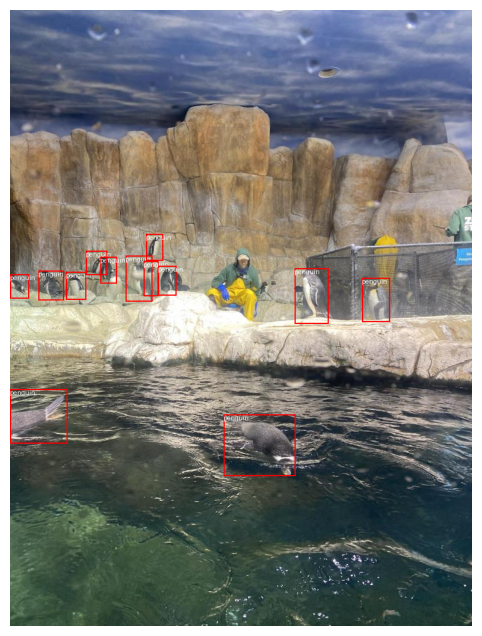

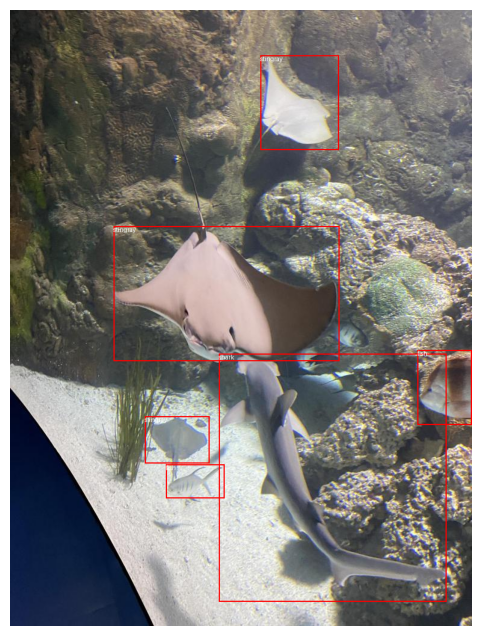

In [16]:
# Function to display image with bounding boxes
def visualize_image(img_id):
    img_file = os.path.join(directory_path, image_map[img_id])
    img = Image.open(img_file)
    draw = ImageDraw.Draw(img)
    
    for ann in image_annotations[img_id]:
        bbox = ann['bbox']
        category_id = ann['category_id']
        class_name = category_map[category_id]
        
        # Bounding box coordinates
        x, y, width, height = bbox
        draw.rectangle([x, y, x+width, y+height], outline="red", width=2)
        draw.text((x, y), class_name, fill="white")
    
    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Visualize 5 images
for img_id in list(image_map.keys())[10:15]:
    visualize_image(img_id)

# Main Code for Faster RCNN Training 
## 1.1 Installing Packages

In [19]:
# !pip3 install pycocotools torchsummary

## 1.2 Loading Packages

In [20]:
import os
import numpy as np
import pandas as pd

# Import necessary libraries for data transformation and dataset handling
import albumentations as A  # For data augmentation
from albumentations.pytorch import ToTensorV2  # To convert images to tensor
from torch.utils.data import Dataset, DataLoader  # PyTorch data handling
from pycocotools.coco import COCO  # COCO format handling
import cv2  # For image loading and processing
import torch  # PyTorch main library
from torchvision import models  # Pretrained models from PyTorch
import torch.optim as optim  # Optimizers
from tqdm import tqdm  # For progress bar in training loop
import warnings  # For managing warnings

from torchinfo import summary
import torch
from typing import List, Tuple
import numpy as np

import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import random

## 1.2 Ignore warnings

In [21]:
# Suppress warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## 1.3 Transform the input images

In [22]:
# Data transformations for training data
def get_train_transforms():
    """
    Returns transformation pipeline for training images with augmentations 
    including resizing, flipping, brightness/contrast adjustments, and color jitter.
    """
    return A.Compose([
        A.Resize(600, 600),  # Resize images to 600x600 pixels
        A.HorizontalFlip(p=0.3),  # Apply horizontal flip with a probability of 30%
        A.VerticalFlip(p=0.3),  # Apply vertical flip with a probability of 30%
        A.RandomBrightnessContrast(p=0.1),  # Adjust brightness/contrast with 10% probability
        A.ColorJitter(p=0.1),  # Random color jitter with 10% probability
        ToTensorV2()  # Convert the image to a PyTorch tensor
    ], bbox_params=A.BboxParams(format='coco'))  # Bounding box format in COCO style


## 1.4 Transform Test Images

In [23]:
# Data transformations for test data (without augmentations)
def get_test_transforms():
    """
    Returns transformation pipeline for test images, only resizing and tensor conversion.
    """
    return A.Compose([
        A.Resize(600, 600),  # Resize images to 600x600 pixels
        ToTensorV2()  # Convert the image to a PyTorch tensor
    ], bbox_params=A.BboxParams(format='coco'))  # Bounding box format in COCO style


## 1.5 Creating Custom Class for data laoding

In [24]:
# Custom Dataset class for Aquarium Detection
class AquariumDetection(Dataset):
    def __init__(self, root, split='train', transforms=None):
        """
        Initializes dataset with root path, split (train/test), and transformations.
        Loads COCO annotations and filters images with annotations.

        Parameters:
        - root: path to the dataset
        - split: 'train' or 'test' to select dataset split
        - transforms: data augmentation transformations
        """
        self.root = root
        self.split = split
        self.transforms = transforms
        # Load COCO format annotations
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json"))
        # Filter image IDs that have at least one annotation
        self.ids = [img_id for img_id in sorted(self.coco.imgs.keys())
                    if len(self.coco.getAnnIds(img_id)) > 0]
    
    def __getitem__(self, index):
        """
        Retrieves image and target (bounding boxes and labels) by index.
        
        Parameters:
        - index: index to select image and target
        Returns:
        - Transformed image tensor and target dictionary
        """
        img_id = self.ids[index]  # Get image ID
        image = self.load_image(img_id)  # Load image using ID
        annotations = self.coco.loadAnns(self.coco.getAnnIds(img_id))  # Load annotations
        boxes = [ann['bbox'] + [ann['category_id']] for ann in annotations]  # Extract bounding boxes

        # Apply transformations if specified
        if self.transforms:
            transformed = self.transforms(image=image, bboxes=boxes)
            image = transformed['image']
            boxes = transformed['bboxes']
        
        # Convert bounding boxes to tensor format (x_min, y_min, x_max, y_max)
        boxes = torch.tensor([[x, y, x + w, y + h] for x, y, w, h, _ in boxes], dtype=torch.float32)
        labels = torch.tensor([ann['category_id'] for ann in annotations], dtype=torch.int64)  # Labels
        iscrowd = torch.tensor([ann.get('iscrowd', 0) for ann in annotations], dtype=torch.int64)  # Crowd labels

        # Prepare target dictionary
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id]),
            'area': (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),  # Area of boxes
            'iscrowd': iscrowd
        }
        return image.div(255), target  # Normalize image

    def load_image(self, img_id):
        """
        Loads image from file path using OpenCV and converts to RGB.
        
        Parameters:
        - img_id: image ID to load
        Returns:
        - Loaded RGB image
        """
        img_path = self.coco.loadImgs(img_id)[0]['file_name']
        image = cv2.imread(os.path.join(self.root, self.split, img_path))
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB format

    def __len__(self):
        """Returns the total number of images with annotations in the dataset."""
        return len(self.ids)

## 1.5 Initialising the custom class data processor

In [25]:
# Model and training setup
dataset_path = "/kaggle/input/aquarium-dataset/Aquarium Combined/"
train_dataset = AquariumDetection(root=dataset_path, transforms=get_train_transforms())

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


## 1.6 Initialising Faster RCNN model

In [26]:
# Modify the Faster R-CNN model for custom class predictions
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(
    model.roi_heads.box_predictor.cls_score.in_features, len(train_dataset.coco.cats)
)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth
100%|██████████| 74.2M/74.2M [00:00<00:00, 165MB/s] 


## 1.7 Checking Model Summary

In [27]:
def print_model_summary(model, input_size: Tuple[int, int, int, int] = (1, 3, 600, 600)):
    """
    Prints a detailed summary of a PyTorch model, similar to Keras model.summary()
    
    Parameters:
    - model: PyTorch model to summarize
    - input_size: Tuple of (batch_size, channels, height, width) for input tensor
    """
    try:
        # Create a dummy input tensor for the model
        dummy_input = torch.randn(input_size)
        
        # Get model summary using torchinfo
        model_stats = summary(
            model,
            input_size=(input_size,),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"]
        )
        
        # Print additional model statistics
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print("\nModel Statistics:")
        print(f"Total Parameters: {total_params:,}")
        print(f"Trainable Parameters: {trainable_params:,}")
        print(f"Non-trainable Parameters: {total_params - trainable_params:,}")
        
        return model_stats
    
    except Exception as e:
        print(f"Error generating model summary: {str(e)}")
        print("\nFalling back to basic summary...")
        
        # Fallback to basic parameter summary
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        print("\nBasic Model Statistics:")
        print(f"Total Parameters: {total_params:,}")
        print(f"Trainable Parameters: {trainable_params:,}")
        print(f"Non-trainable Parameters: {total_params - trainable_params:,}")

In [28]:
# Print model summary
print_model_summary(model)


Model Statistics:
Total Parameters: 18,960,979
Trainable Parameters: 18,902,083
Non-trainable Parameters: 58,896


Layer (type (var_name))                                           Input Shape          Output Shape         Param #              Trainable
FasterRCNN (FasterRCNN)                                           [1, 3, 600, 600]     [0, 4]               --                   Partial
├─GeneralizedRCNNTransform (transform)                            [1, 3, 600, 600]     [1, 3, 800, 800]     --                   --
├─BackboneWithFPN (backbone)                                      [1, 3, 800, 800]     [1, 256, 13, 13]     --                   Partial
│    └─IntermediateLayerGetter (body)                             [1, 3, 800, 800]     [1, 960, 25, 25]     --                   Partial
│    │    └─Conv2dNormActivation (0)                              [1, 3, 800, 800]     [1, 16, 400, 400]    (432)                False
│    │    └─InvertedResidual (1)                                  [1, 16, 400, 400]    [1, 16, 400, 400]    (400)                False
│    │    └─InvertedResidual (2)                

## 1.8 Initialise Optimisers

In [29]:
# Optimizer setup with SGD
params = [p for p in model.parameters() if p.requires_grad]  # Only parameters with gradients
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)  # SGD optimizer


## 1.9 Creating fucntion to train one epoch

In [30]:
# Training loop for one epoch
def train_one_epoch(model, optimizer, loader, device, epoch):
    """
    Trains the model for one epoch, accumulating and printing losses.
    
    Parameters:
    - model: neural network model
    - optimizer: optimizer for backpropagation
    - loader: dataloader for training data
    - device: device to run computations (CPU/GPU)
    - epoch: current epoch number
    """
    model.train()
    total_loss = 0  # Initialize total loss for epoch
    loss_dict_accumulated = {  # Initialize dictionary to accumulate losses
        'loss_classifier': 0,
        'loss_box_reg': 0,
        'loss_objectness': 0,
        'loss_rpn_box_reg': 0
    }
    num_batches = len(loader)

    # Iterate through batches of images and targets
    for images, targets in tqdm(loader):
        images = [img.to(device) for img in images]  # Move images to device
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  # Move targets to device

        # Calculate model losses
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())  # Sum all losses
        total_loss += losses.item()

        # Accumulate each loss type for averaging
        for key, loss_val in loss_dict.items():
            loss_dict_accumulated[key] += loss_val.item()

        # Backpropagation step
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    # Calculate and print average losses
    avg_total_loss = total_loss / num_batches
    avg_loss_dict = {key: val / num_batches for key, val in loss_dict_accumulated.items()}
    print(f"Epoch {epoch}:")
    print(f"  Average Total Loss: {avg_total_loss:.4f}")
    for loss_name, avg_loss in avg_loss_dict.items():
        print(f"  Average {loss_name}: {avg_loss:.4f}")


## 1.10 Initialise data loaders

In [32]:
# Dataloader and Training Execution
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Set device
# model.to(device)  # Move model to device

## 1.11 Main training for 10 epochs

In [33]:
# Training loop across 10 epochs
for epoch in range(10):
    train_one_epoch(model, optimizer, train_loader, device, epoch)

100%|██████████| 112/112 [00:19<00:00,  5.76it/s]


Epoch 0:
  Average Total Loss: 1.0500
  Average loss_classifier: 0.5023
  Average loss_box_reg: 0.4234
  Average loss_objectness: 0.0929
  Average loss_rpn_box_reg: 0.0315


100%|██████████| 112/112 [00:17<00:00,  6.39it/s]


Epoch 1:
  Average Total Loss: 0.8285
  Average loss_classifier: 0.3847
  Average loss_box_reg: 0.3556
  Average loss_objectness: 0.0607
  Average loss_rpn_box_reg: 0.0275


100%|██████████| 112/112 [00:17<00:00,  6.36it/s]


...

Epoch 7:
  Average Total Loss: 0.6359
  Average loss_classifier: 0.2389
  Average loss_box_reg: 0.3448
  Average loss_objectness: 0.0312
  Average loss_rpn_box_reg: 0.0210


100%|██████████| 112/112 [00:17<00:00,  6.31it/s]


Epoch 8:
  Average Total Loss: 0.6064
  Average loss_classifier: 0.2248
  Average loss_box_reg: 0.3309
  Average loss_objectness: 0.0303
  Average loss_rpn_box_reg: 0.0203


100%|██████████| 112/112 [00:17<00:00,  6.37it/s]

Epoch 9:
  Average Total Loss: 0.5916
  Average loss_classifier: 0.2145
  Average loss_box_reg: 0.3296
  Average loss_objectness: 0.0273
  Average loss_rpn_box_reg: 0.0203


## Plotting images with predicitons

In [34]:
# Define a helper function for visualization
def plot_images_with_predictions(original_image, predictions, labels_map):
    plt.figure(figsize=(12, 6))
    
    # Display original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis("off")
    
    # Display image with predictions
    plt.subplot(1, 2, 2)
    plt.imshow(original_image)
    plt.title("Predicted Objects")
    
    # Draw bounding boxes and labels on the predicted image
    for box, label, score in zip(predictions['boxes'], predictions['labels'], predictions['scores']):
        if score >= 0.5:  # Confidence threshold
            box = box.int().tolist()
            plt.gca().add_patch(plt.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                              linewidth=2, edgecolor='red', facecolor='none'))
            plt.text(box[0], box[1] - 5, f"{labels_map[label.item()]}: {score:.2f}", color='red', fontsize=12)
    
    plt.axis("off")
    plt.show()

## Model predicitons

In [35]:
# Evaluation function
def evaluate(model, test_loader, device, labels_map):
    model.eval()
    with torch.no_grad():
        for images, targets in test_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            # Process each image in the batch
            for i, output in enumerate(outputs):
                original_image = F.to_pil_image(images[i].cpu())
                
                # Move tensors to CPU for visualization
                predictions = {
                    'boxes': output['boxes'].cpu(),
                    'labels': output['labels'].cpu(),
                    'scores': output['scores'].cpu()
                }
                
                # Display the original and predicted image side by side
                plot_images_with_predictions(original_image, predictions, labels_map)
                
            # Break after first batch to limit visualization to a few images
            break

## Initialising predicitons

{0: 'creatures', 1: 'fish', 2: 'jellyfish', 3: 'penguin', 4: 'puffin', 5: 'shark', 6: 'starfish', 7: 'stingray'}
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


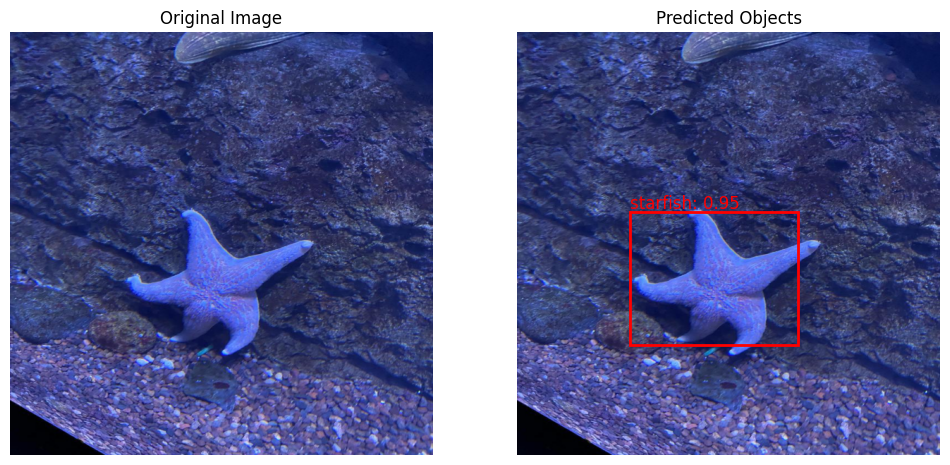

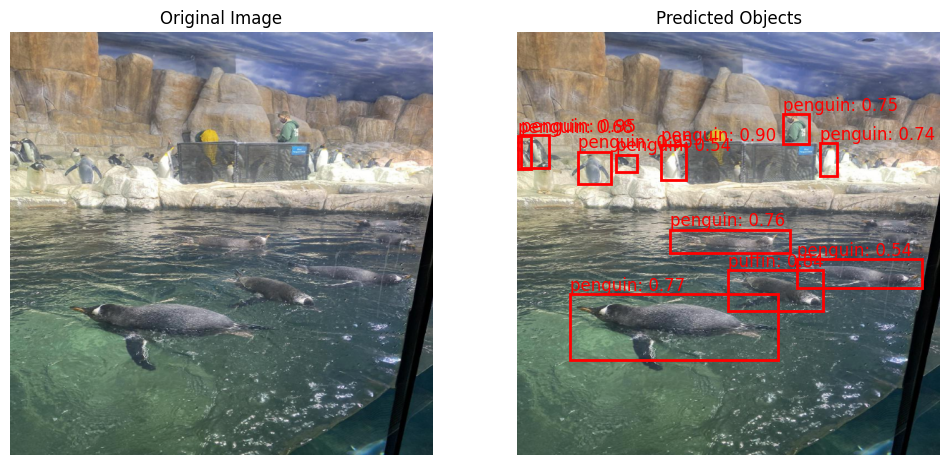

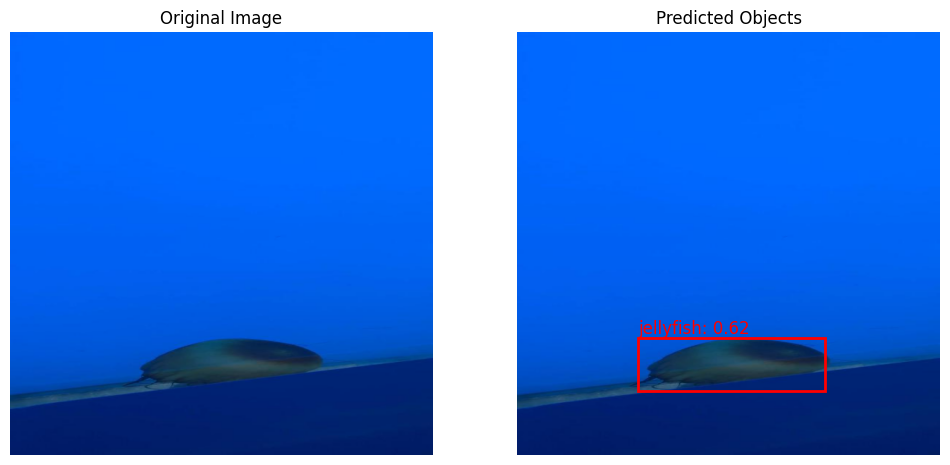

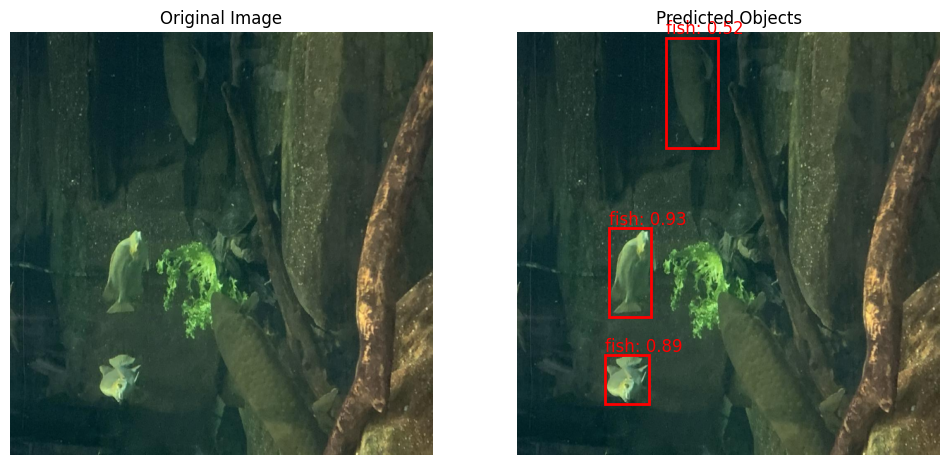

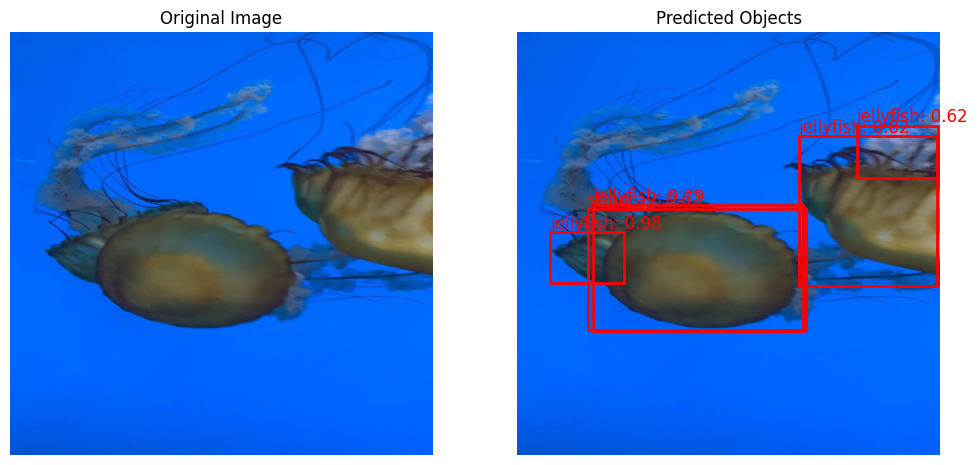

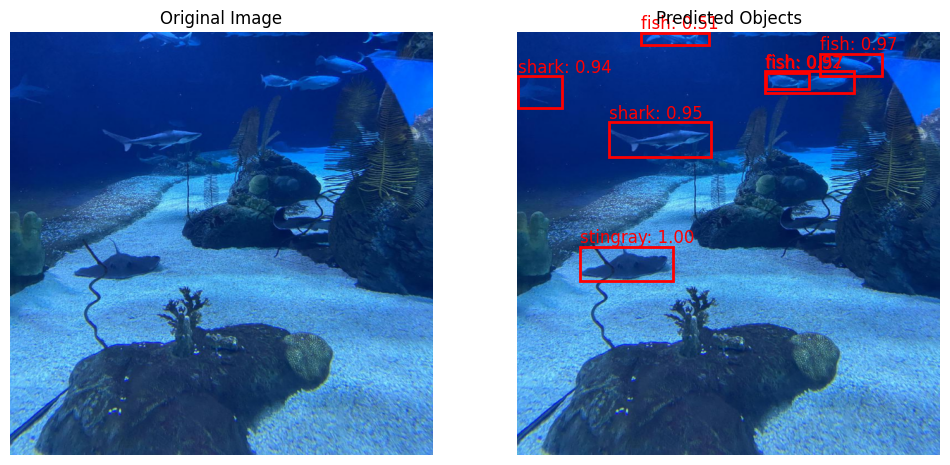

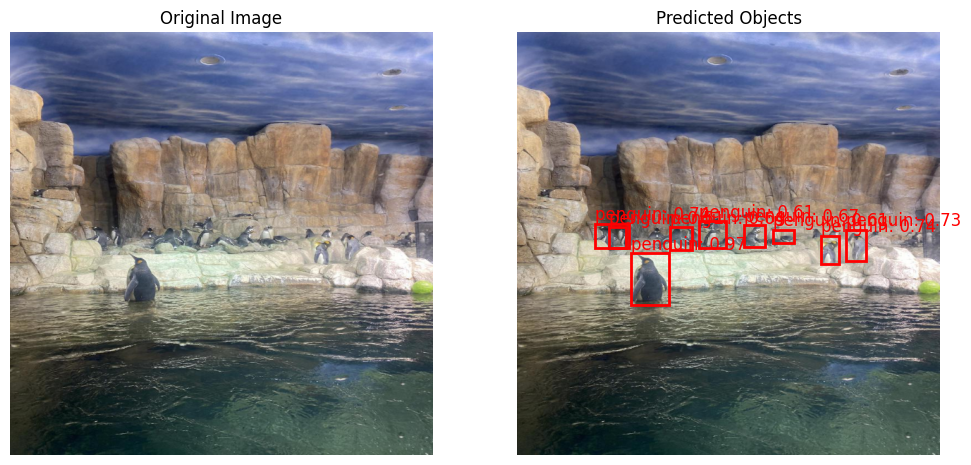

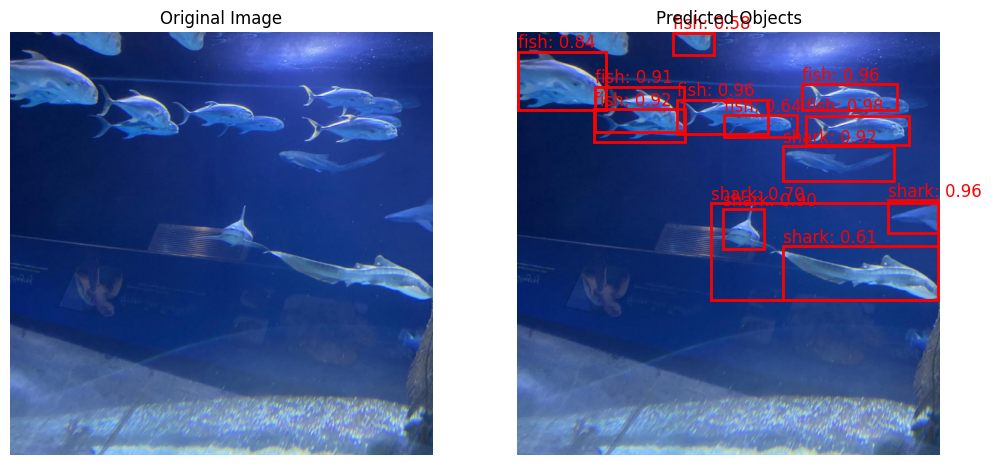

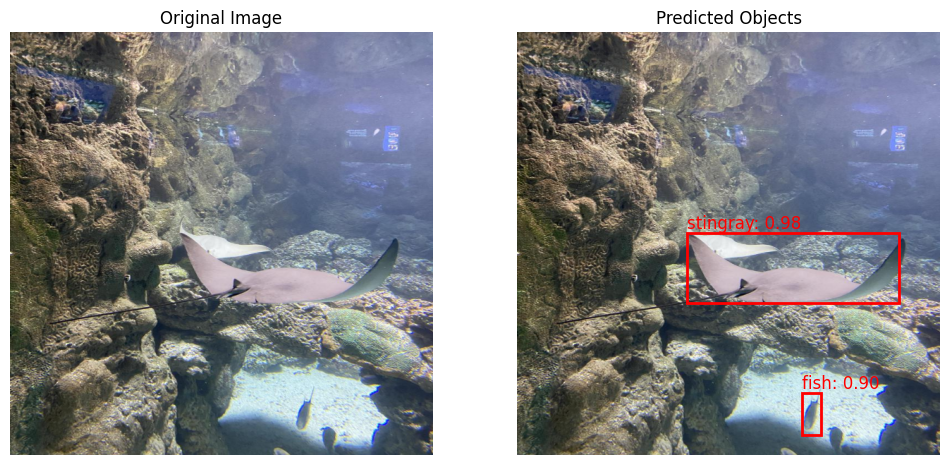

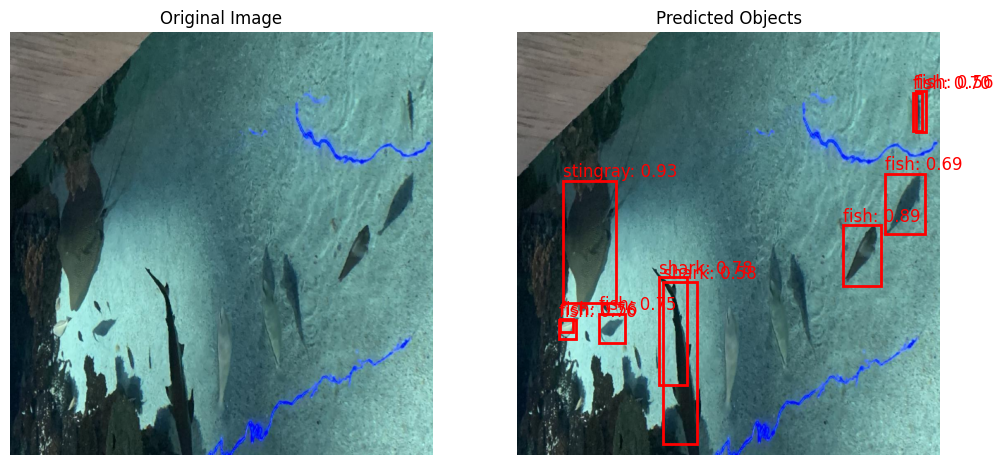

In [36]:
# Load labels map from the dataset
labels_map = {v['id']: v['name'] for v in train_dataset.coco.cats.values()}
print(labels_map)

# Create test DataLoader
test_dataset = AquariumDetection(root=dataset_path, split='test', transforms=get_test_transforms())
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# Run evaluation
evaluate(model, test_loader, device, labels_map)

# Extra Code

In [37]:
# Data transformations for training data
def get_train_transforms():
    """
    Returns transformation pipeline for training images with augmentations 
    including resizing, flipping, brightness/contrast adjustments, and color jitter.
    """
    return A.Compose([
        A.Resize(600, 600),  # Resize images to 600x600 pixels
        A.HorizontalFlip(p=0.3),  # Apply horizontal flip with a probability of 30%
        A.VerticalFlip(p=0.3),  # Apply vertical flip with a probability of 30%
        A.RandomBrightnessContrast(p=0.1),  # Adjust brightness/contrast with 10% probability
        A.ColorJitter(p=0.1),  # Random color jitter with 10% probability
        ToTensorV2()  # Convert the image to a PyTorch tensor
    ], bbox_params=A.BboxParams(format='coco'))  # Bounding box format in COCO style

# Data transformations for test data (without augmentations)
def get_test_transforms():
    """
    Returns transformation pipeline for test images, only resizing and tensor conversion.
    """
    return A.Compose([
        A.Resize(600, 600),  # Resize images to 600x600 pixels
        ToTensorV2()  # Convert the image to a PyTorch tensor
    ], bbox_params=A.BboxParams(format='coco'))  # Bounding box format in COCO style

# Custom Dataset class for Aquarium Detection
class AquariumDetection(Dataset):
    def __init__(self, root, split='train', transforms=None):
        """
        Initializes dataset with root path, split (train/test), and transformations.
        Loads COCO annotations and filters images with annotations.

        Parameters:
        - root: path to the dataset
        - split: 'train' or 'test' to select dataset split
        - transforms: data augmentation transformations
        """
        self.root = root
        self.split = split
        self.transforms = transforms
        # Load COCO format annotations
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json"))
        # Filter image IDs that have at least one annotation
        self.ids = [img_id for img_id in sorted(self.coco.imgs.keys())
                    if len(self.coco.getAnnIds(img_id)) > 0]
    
    def __getitem__(self, index):
        """
        Retrieves image and target (bounding boxes and labels) by index.
        
        Parameters:
        - index: index to select image and target
        Returns:
        - Transformed image tensor and target dictionary
        """
        img_id = self.ids[index]  # Get image ID
        image = self.load_image(img_id)  # Load image using ID
        annotations = self.coco.loadAnns(self.coco.getAnnIds(img_id))  # Load annotations
        boxes = [ann['bbox'] + [ann['category_id']] for ann in annotations]  # Extract bounding boxes

        # Apply transformations if specified
        if self.transforms:
            transformed = self.transforms(image=image, bboxes=boxes)
            image = transformed['image']
            boxes = transformed['bboxes']
        
        # Convert bounding boxes to tensor format (x_min, y_min, x_max, y_max)
        boxes = torch.tensor([[x, y, x + w, y + h] for x, y, w, h, _ in boxes], dtype=torch.float32)
        labels = torch.tensor([ann['category_id'] for ann in annotations], dtype=torch.int64)  # Labels
        iscrowd = torch.tensor([ann.get('iscrowd', 0) for ann in annotations], dtype=torch.int64)  # Crowd labels

        # Prepare target dictionary
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id]),
            'area': (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),  # Area of boxes
            'iscrowd': iscrowd
        }
        return image.div(255), target  # Normalize image

    def load_image(self, img_id):
        """
        Loads image from file path using OpenCV and converts to RGB.
        
        Parameters:
        - img_id: image ID to load
        Returns:
        - Loaded RGB image
        """
        img_path = self.coco.loadImgs(img_id)[0]['file_name']
        image = cv2.imread(os.path.join(self.root, self.split, img_path))
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB format

    def __len__(self):
        """Returns the total number of images with annotations in the dataset."""
        return len(self.ids)

# Model and training setup
dataset_path = "/kaggle/input/aquarium-dataset/Aquarium Combined/"
train_dataset = AquariumDetection(root=dataset_path, transforms=get_train_transforms())


# Modify the Faster R-CNN model for custom class predictions
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(
    model.roi_heads.box_predictor.cls_score.in_features, len(train_dataset.coco.cats)
)

# Optimizer setup with SGD
params = [p for p in model.parameters() if p.requires_grad]  # Only parameters with gradients
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)  # SGD optimizer

# Training loop for one epoch
def train_one_epoch(model, optimizer, loader, device, epoch):
    """
    Trains the model for one epoch, accumulating and printing losses.
    
    Parameters:
    - model: neural network model
    - optimizer: optimizer for backpropagation
    - loader: dataloader for training data
    - device: device to run computations (CPU/GPU)
    - epoch: current epoch number
    """
    model.train()
    total_loss = 0  # Initialize total loss for epoch
    loss_dict_accumulated = {  # Initialize dictionary to accumulate losses
        'loss_classifier': 0,
        'loss_box_reg': 0,
        'loss_objectness': 0,
        'loss_rpn_box_reg': 0
    }
    num_batches = len(loader)

    # Iterate through batches of images and targets
    for images, targets in tqdm(loader):
        images = [img.to(device) for img in images]  # Move images to device
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  # Move targets to device

        # Calculate model losses
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())  # Sum all losses
        total_loss += losses.item()

        # Accumulate each loss type for averaging
        for key, loss_val in loss_dict.items():
            loss_dict_accumulated[key] += loss_val.item()

        # Backpropagation step
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    # Calculate and print average losses
    avg_total_loss = total_loss / num_batches
    avg_loss_dict = {key: val / num_batches for key, val in loss_dict_accumulated.items()}
    print(f"Epoch {epoch}:")
    print(f"  Average Total Loss: {avg_total_loss:.4f}")
    for loss_name, avg_loss in avg_loss_dict.items():
        print(f"  Average {loss_name}: {avg_loss:.4f}")

# Dataloader and Training Execution
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Set device
model.to(device)  # Move model to device

# Training loop across 10 epochs
for epoch in range(10):
    train_one_epoch(model, optimizer, train_loader, device, epoch)


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


100%|██████████| 112/112 [00:19<00:00,  5.76it/s]


Epoch 0:
  Average Total Loss: 1.0320
  Average loss_classifier: 0.4894
  Average loss_box_reg: 0.4190
  Average loss_objectness: 0.0931
  Average loss_rpn_box_reg: 0.0306


100%|██████████| 112/112 [00:19<00:00,  5.76it/s]


Epoch 1:
  Average Total Loss: 0.8070
  Average loss_classifier: 0.3722
  Average loss_box_reg: 0.3482
  Average loss_objectness: 0.0598
  Average loss_rpn_box_reg: 0.0268


...

Epoch 7:
  Average Total Loss: 0.6248
  Average loss_classifier: 0.2328
  Average loss_box_reg: 0.3397
  Average loss_objectness: 0.0315
  Average loss_rpn_box_reg: 0.0208


100%|██████████| 112/112 [00:17<00:00,  6.33it/s]


Epoch 8:
  Average Total Loss: 0.6089
  Average loss_classifier: 0.2254
  Average loss_box_reg: 0.3341
  Average loss_objectness: 0.0288
  Average loss_rpn_box_reg: 0.0206


100%|██████████| 112/112 [00:17<00:00,  6.38it/s]

Epoch 9:
  Average Total Loss: 0.6138
  Average loss_classifier: 0.2264
  Average loss_box_reg: 0.3393
  Average loss_objectness: 0.0275
  Average loss_rpn_box_reg: 0.0206
